In [2]:
import jax
import jax.numpy as np
import dLux as dl
import dLuxToliman as dlt
import matplotlib.pyplot as plt
import scipy
from matplotlib.patches import Rectangle

jax.config.update("jax_enable_x64", True)

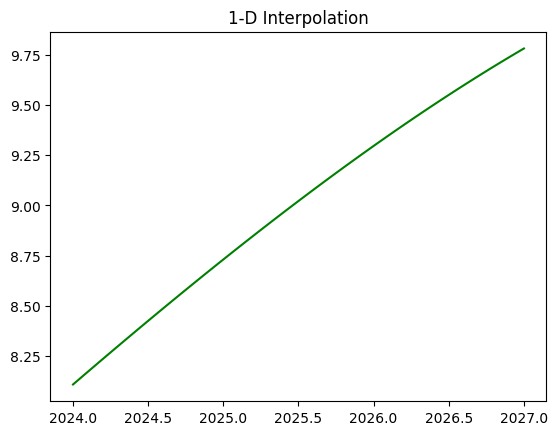

In [3]:
time = np.linspace(2023, 2027, 5)
spacing = [7.451, 8.109, 8.731, 9.296, 9.781]

sep = scipy.interpolate.make_splrep(time, spacing, s=0)
xnew = np.linspace(2024, 2027, 100)
ynew = sep(xnew) + 3e-6 * np.sin(2 * np.pi * xnew)
plt.title("1-D Interpolation")
plt.plot(xnew, ynew, "-", color="green")
plt.show()

In [9]:
import scipy.interpolate

pixels = 128
aper = dlt.TolimanOpticalSystem(psf_npixels=pixels).aperture.transmission.T
# wavelengths = np.linspace(530e-9, 640e-9, 1)


basis = np.load("basis_32.npy")
coeffs = np.load("coeff_hist.npy")
for i in range(1):
    climb = dlt.layers.optical_layers.ApplyBasisCLIMB(
        basis, 5.85e-7, np.zeros(coeffs[-1].shape)
    )
    opd = climb.get_binary_phase()

    source = dlt.AlphaCen(n_wavels=1, separation=8, position_angle=-90)
    # source = dl.PointSource([585e-9], position=(0, 0))
    optics = dlt.TolimanOpticalSystem(
        psf_npixels=128, mask=climb, oversample=20
    )

    psf = optics.model(source=source)

    plt.imsave(
        f"Generated Files/psf_frame_{i:03d}.png",
        psf**0.5,
        cmap="magma",
    )

    plt.imsave(
        f"Generated Files/frame_{i:03d}.png",
        aper * opd,
        cmap="inferno",
        vmin=0,
        vmax=1,
    )

In [ ]:
import imageio
import os

# Folder containing the images
folder = "Generated Files"
# Get all PNG files and sort them
images = sorted(
    [
        img
        for img in os.listdir(folder)
        if img.endswith(".png") and img.startswith("alpha_")
    ]
)

# Read images and create gif
frames = [imageio.imread(os.path.join(folder, img)) for img in images]
gif_path = os.path.join(folder, "animation.gif")
imageio.mimsave(gif_path, frames, duration=0.001, loop=0)

print(f"GIF saved to {gif_path}")

/var/folders/2l/9nw6bq2n5r3759l7ckh_4mv40000gn/T/ipykernel_2146/3633265032.py:16: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  frames = [imageio.imread(os.path.join(folder, img)) for img in images]


GIF saved to Generated Files/animation.gif


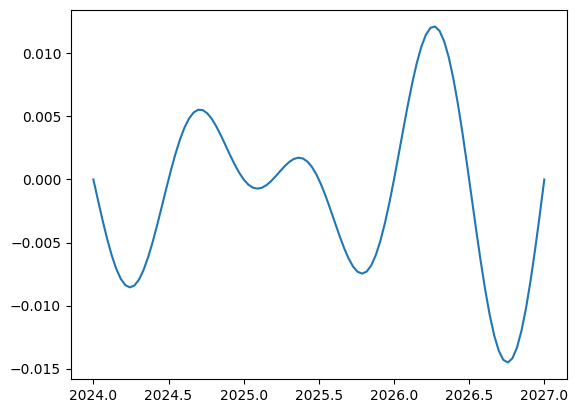

In [34]:
pixels = 128
n = 150
aper = dlt.TolimanOpticalSystem(psf_npixels=pixels).aperture.transmission.T
# wavelengths = np.linspace(530e-9, 640e-9, 1)

basis = np.load("basis_32.npy")
coeffs = np.load("coeff_hist.npy")
climb = dlt.layers.optical_layers.ApplyBasisCLIMB(basis, 5.85e-7, coeffs[-1])
opd = climb.get_binary_phase()
single_pixel = []
second_pixel = []
for i in range(len(ynew)):

    source = dlt.AlphaCen(n_wavels=3, separation=ynew[i], position_angle=-90)
    optics = dlt.TolimanOpticalSystem(psf_npixels=100, oversample=1)

    psf = optics.model(source=source)

    # fig, ax = plt.subplots()
    # ax.set_aspect("equal")
    # rect = Rectangle((54.5, 46.5), 1, 1, angle=0.0, color="green")
    # ax.add_patch(rect)
    # ax.imshow(psf, cmap="inferno")
    # fig.savefig("test_centroiding.png")
    second_pixel.append(psf[55, 47])
    single_pixel.append(psf[59, 30])

    plt.imsave(
        f"Generated Files/alpha_frame_{i:03d}.png",
        psf,
        cmap="grey",
    )
# np.save("Generated Files/toliman_image{i:03d}.npy", psf)
# print(single_pixel)
import numpy as np

fig, ax = plt.subplots()
second_pixel = second_pixel - np.loadtxt("brightness_2ndPixel.csv")
plt.plot(xnew, second_pixel)

np.savetxt("brightness_2ndPixel_2.csv", second_pixel, delimiter=",")